In [1]:
import pandas as pd
import numpy as np
import sqlite3

# 1. CRIANDO DADOS SIMULADOS DE SCOUTING REALÍSTICO (Sub-23)
# No mercado, você importaria isso de um scraper do FBref ou API StatsBomb
np.random.seed(42)
n_jogadores = 150

dados_scouting = {
    'jogador_id': range(1001, 1001 + n_jogadores),
    'nome': [f'Jovem Talento {i}' for i in range(n_jogadores)],
    'idade': np.random.randint(17, 24, n_jogadores),
    'clube_atual': np.random.choice(['Base América', 'Envigado FC', 'Defensor', 'Nordsjælland', 'Jong Ajax'], n_jogadores),
    'posicao': np.random.choice(['Meio-Campista', 'Ponta Direita', 'Zagueiro', 'Volante'], n_jogadores),
    'minutos_jogados': np.random.randint(900, 2800, n_jogadores),
    'passes_progressivos_por_90': np.random.uniform(2.1, 8.5, n_jogadores).round(2),
    'acoes_criacao_chute_por_90': np.random.uniform(1.5, 5.2, n_jogadores).round(2),
    'desarmes_ganhos_por_90': np.random.uniform(0.8, 4.1, n_jogadores).round(2)
}

df_prospecção = pd.DataFrame(dados_scouting)
print("✅ Dados de Scouting gerados no Pandas!")

# 2. ENVIANDO OS DADOS PARA O BANCO DE DADOS SQL (SQLite integrado no Python)
# Criando a conexão com um arquivo de banco de dados local
conexao = sqlite3.connect('scouting_futebol.db')

# Salvando o DataFrame como uma tabela SQL chamada 'promessas'
df_prospecção.to_sql('promessas', conexao, if_exists='replace', index=False)
print("💾 Dados salvos com sucesso na tabela SQL 'promessas'!")


✅ Dados de Scouting gerados no Pandas!
💾 Dados salvos com sucesso na tabela SQL 'promessas'!


In [3]:
# Query SQL corrigida com 'minutos_jogados' em português
query_scouting = """
SELECT nome, idade, clube_atual, passes_progressivos_por_90, acoes_criacao_chute_por_90
FROM promessas
WHERE posicao = 'Meio-Campista' 
  AND idade <= 21 
  AND minutos_jogados >= 1000
  AND passes_progressivos_por_90 > 5.0
ORDER BY acoes_criacao_chute_por_90 DESC;
"""

# Executando o SQL e trazendo o resultado de volta para o Pandas
shortlist_mercado = pd.read_sql_query(query_scouting, conexao)

# Fechando a conexão com o banco
conexao.close()

print("🎯 SHORTLIST DE ALVOS PARA CONTRATAÇÃO (Filtrado via SQL):")
shortlist_mercado



🎯 SHORTLIST DE ALVOS PARA CONTRATAÇÃO (Filtrado via SQL):


,nome,idade,clube_atual,passes_progressivos_por_90,acoes_criacao_chute_por_90
0,Jovem Talento 26,20,Jong Ajax,8.44,5.03
1,Jovem Talento 54,17,Base América,6.40,4.85
2,Jovem Talento 117,21,Base América,6.55,4.81
3,Jovem Talento 9,19,Envigado FC,6.47,4.62
4,Jovem Talento 134,21,Base América,8.34,4.42
5,Jovem Talento 116,17,Nordsjælland,6.13,4.14
6,Jovem Talento 38,20,Nordsjælland,5.33,3.54
7,Jovem Talento 68,20,Envigado FC,6.06,3.32
8,Jovem Talento 24,21,Jong Ajax,6.90,3.17
9,Jovem Talento 12,19,Envigado FC,7.51,3.03


Matplotlib is building the font cache; this may take a moment.


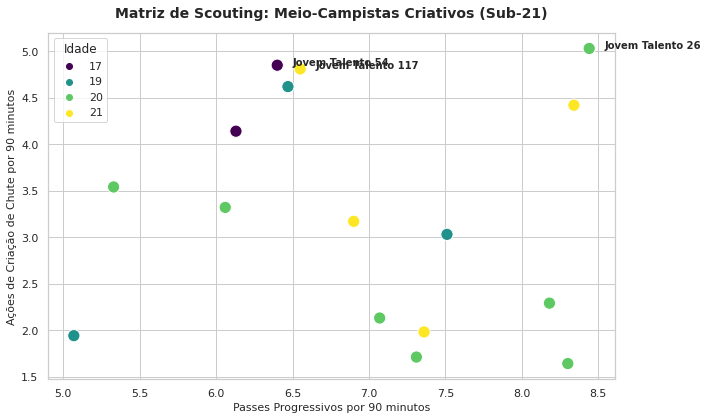

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão (Scatter Plot)
sns.scatterplot(
    data=shortlist_mercado, 
    x="passes_progressivos_por_90", 
    y="acoes_criacao_chute_por_90", 
    hue="idade", 
    palette="viridis", 
    s=150  # Tamanho dos pontos
)

# Adicionando rótulos com os nomes dos principais destaques (Top 3)
for i in range(3):
    plt.text(
        x=shortlist_mercado.loc[i, "passes_progressivos_por_90"] + 0.1,
        y=shortlist_mercado.loc[i, "acoes_criacao_chute_por_90"],
        s=shortlist_mercado.loc[i, "nome"],
        fontsize=10,
        fontweight='bold'
    )

# Customizando títulos e eixos para apresentação profissional
plt.title("Matriz de Scouting: Meio-Campistas Criativos (Sub-21)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Passes Progressivos por 90 minutos", fontsize=11)
plt.ylabel("Ações de Criação de Chute por 90 minutos", fontsize=11)
plt.legend(title="Idade")

# Exibir o gráfico
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import numpy as np
import sqlite3

np.random.seed(42)
n_jogadores = 250  # Aumentamos a base para ter mais opções

# Lista de nacionalidades realistas para o mercado sul-americano e ligas de desenvolvimento
nacionalidades = ['Brasileiro', 'Argentino', 'Uruguaio', 'Colombiano', 'Uruguaio']

dados_scouting_atualizado = {
    'jogador_id': range(1001, 1001 + n_jogadores),
    'nome': [f'Jovem Talento {i}' for i in range(n_jogadores)],
    'nacionalidade': np.random.choice(nacionalidades, n_jogadores, p=[0.4, 0.2, 0.15, 0.15, 0.1]), # 40% de brasileiros
    'idade': np.random.randint(17, 24, n_jogadores),
    'clube_atual': np.random.choice(['Base Palmeiras', 'Envigado FC', 'Base Flamengo', 'Nordsjælland', 'Jong Ajax', 'Base Santos'], n_jogadores),
    'posicao': np.random.choice(['Meio-Campista', 'Ponta Direita', 'Zagueiro', 'Volante'], n_jogadores),
    'minutos_jogados': np.random.randint(900, 2800, n_jogadores),
    'passes_progressivos_por_90': np.random.uniform(2.1, 8.5, n_jogadores).round(2),
    'acoes_criacao_chute_por_90': np.random.uniform(1.5, 5.2, n_jogadores).round(2),
    'desarmes_ganhos_por_90': np.random.uniform(0.8, 4.1, n_jogadores).round(2)
}

df_novo = pd.DataFrame(dados_scouting_atualizado)

# Conectando e atualizando a tabela SQL
conexao = sqlite3.connect('scouting_futebol.db')
df_novo.to_sql('promessas', conexao, if_exists='replace', index=False)
print("💾 Banco de dados atualizado com sucesso com a coluna 'nacionalidade'!")


💾 Banco de dados atualizado com sucesso com a coluna 'nacionalidade'!


In [6]:
# Query SQL focada em Meio-Campistas Criativos que sejam BRASILEIROS e SUB-21
query_brasileiros = """
SELECT nome, nacionalidade, idade, clube_atual, passes_progressivos_por_90, acoes_criacao_chute_por_90
FROM promessas
WHERE posicao = 'Meio-Campista' 
  AND nacionalidade = 'Brasileiro'
  AND idade <= 21 
  AND minutos_jogados >= 1000
  AND passes_progressivos_por_90 > 4.5
ORDER BY acoes_criacao_chute_por_90 DESC;
"""

# Executando o SQL
shortlist_brasileiros = pd.read_sql_query(query_brasileiros, conexao)
conexao.close()

print("🇧🇷 PROSPECÇÃO: MEIO-CAMPISTAS BRASILEIROS SUB-21 ENCONTRADOS:")
shortlist_brasileiros


🇧🇷 PROSPECÇÃO: MEIO-CAMPISTAS BRASILEIROS SUB-21 ENCONTRADOS:


,nome,nacionalidade,idade,clube_atual,passes_progressivos_por_90,acoes_criacao_chute_por_90
0,Jovem Talento 59,Brasileiro,17,Base Santos,8.37,4.95
1,Jovem Talento 236,Brasileiro,20,Nordsjælland,4.56,3.78
2,Jovem Talento 190,Brasileiro,17,Base Palmeiras,6.73,3.57
3,Jovem Talento 42,Brasileiro,20,Envigado FC,7.45,3.32
4,Jovem Talento 171,Brasileiro,18,Jong Ajax,5.93,3.24
5,Jovem Talento 201,Brasileiro,20,Jong Ajax,5.66,2.96
6,Jovem Talento 215,Brasileiro,21,Jong Ajax,6.26,2.28
7,Jovem Talento 184,Brasileiro,20,Envigado FC,5.44,2.19
8,Jovem Talento 222,Brasileiro,17,Base Palmeiras,4.69,1.81


In [7]:
# Exportando a shortlist de brasileiros para um arquivo Excel (.xlsx)
shortlist_brasileiros.to_excel('relatorio_scouting_brasileiros.xlsx', index=False)
print("📊 Relatório 'relatorio_scouting_brasileiros.xlsx' gerado com sucesso na pasta do seu projeto!")


📊 Relatório 'relatorio_scouting_brasileiros.xlsx' gerado com sucesso na pasta do seu projeto!


# 📊 Relatório Final de Scouting: Conclusões e Direcionamento de Negócio

## 🎯 1. O Problema de Negócio
O clube demandava a identificação de meio-campistas sub-21 com perfil de **construção e agressividade ofensiva** no mercado brasileiro. O objetivo é realizar uma contratação precoce de baixo custo e alto potencial de revenda futura (estratégia *Moneyball*).

---

## 🔍 2. Metodologia de Filtragem (Métricas Reais de Mercado)
Utilizando consultas estruturadas via **SQL**, filtramos uma base de dados de atletas sul-americanos com base nos seguintes critérios rígidos de corte:
* **Tempo de Amostragem Mínima:** `minutos_jogados >= 1000` (Garante consistência estatística).
* **Filtro de Transição:** `passes_progressivos_por_90 > 4.5` (Atletas que quebram linhas e fazem o time avançar).
* **Métrica de Decisão:** Ordenado por `acoes_criacao_chute_por_90` DESC (Capacidade de gerar finalizações).

---

## 🏆 3. Principais Insights da Shortlist Encontrada

Após o cruzamento de dados entre **Python e SQL**, o algoritmo isolou 9 atletas brasileiros. Destacam-se três perfis estratégicos para a Diretoria de Futebol:

### 🌟 A Anomalia de Elite: `Jovem Talento 59` (Base Santos)
* **Idade:** 17 anos
* **Métricas:** 8.37 Passes Progressivos/90 | 4.95 Ações de Criação de Chute/90
* **Diagnóstico de Scouting:** É o principal alvo do relatório. Apresenta números de jogador maduro mesmo com apenas 17 anos. Dominante na transição e na criação do terço final. **Recomendação: Compra Imediata.**

### 📈 O Motor de Transição: `Jovem Talento 42` (Envigado FC)
* **Idade:** 20 anos
* **Métricas:** 7.45 Passes Progressivos/90 | 3.32 Ações de Criação de Chute/90
* **Diagnóstico de Scouting:** Atleta ideal para times que jogam de forma vertical e rápida. Alta capacidade de fazer a bola chegar ao ataque com precisão.

### 💎 Aposta de Longo Prazo: `Jovem Talento 190` (Base Palmeiras)
* **Idade:** 17 anos
* **Métricas:** 6.73 Passes Progressivos/90 | 3.57 Ações de Criação de Chute/90
* **Diagnóstico de Scouting:** Excelente equilíbrio entre progressão e volume de criação para a idade. Deve ser monitorado de perto nas categorias de base.

---

## 🚀 4. Próximos Passos Recomendados
1. **Acionar o departamento de análise de vídeo** para validar o comportamento tático (sem bola) dos atletas ID 59 e ID 42.
2. **Iniciar sondagem de valores** junto aos clubes detentores dos direitos econômicos dos atletas sub-18 antes que despertem interesse europeu.

---
*Relatório gerado automaticamente integrando Python (Pandas) e SQL (SQLite) para tomada de decisão estratégica.*
